# Twin-Peak Segmentation Test — Pair Vowel Audio

ทดสอบ twin-peak detection กับไฟล์เสียงที่พูด 2 สระต่อกันในคลิปเดียว

**Convention:** ชื่อโฟลเดอร์ `s1_01`, `s2_02`, ..., `s9_09` — เสียงแรกในคลิปคือสระสั้น (`s1`=อะ) ตามด้วยสระยาว (`01`=อา) เรียงตามลำดับเวลาเสมอ


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydub import AudioSegment
from scipy.signal import find_peaks

FOLDER_TO_THAI = {
    '01':'อา',  '02':'อี',  '03':'อือ', '04':'อู',
    '05':'เอ',  '06':'แอ',  '07':'โอ',  '08':'ออ',
    '09':'เออ', 's1':'อะ',  's2':'อิ',  's3':'อึ',
    's4':'อุ',  's5':'เอะ', 's6':'แอะ', 's7':'โอะ',
    's8':'เอาะ','s9':'เออะ'
}

PAIR_DIR = 'Unseen data/pair'
OUT_DIR  = 'proc_unseen/pair_segmented'
WINDOW_MS = 500          
SILENCE_THRESHOLD = -30.0
CHUNK_MS = 5
MIN_DISTANCE_MS = 300   
PROMINENCE_RATIO = 0.2  

os.makedirs(OUT_DIR, exist_ok=True)


## โหลดรายชื่อไฟล์จากโฟลเดอร์ `pair/`

In [2]:
pair_data = []
for pair_label in sorted(os.listdir(PAIR_DIR)):
    folder = os.path.join(PAIR_DIR, pair_label)
    if os.path.isdir(folder):
        for f in sorted(os.listdir(folder)):
            if f.lower().endswith(('.wav', '.m4a')):
                pair_data.append([os.path.join(folder, f), pair_label])

df_pair = pd.DataFrame(pair_data, columns=['file_path', 'pair_label'])
print(f'Total pair samples : {len(df_pair)}')
print(df_pair['pair_label'].value_counts().sort_index())


Total pair samples : 27
pair_label
s1_01    3
s2_02    3
s3_03    3
s4_04    3
s5_05    3
s6_06    3
s7_07    3
s8_08    3
s9_09    3
Name: count, dtype: int64


## ฟังก์ชัน twin-peak detection + crop 2 segment พร้อม label ตามลำดับ (short ก่อน, long ทีหลัง)

ใช้วิธี `frontback` เพียงวิธีเดียว — หา peak แรกจากหน้า (short vowel) และ peak แรกจากหลังแยกกัน (long vowel)

In [3]:
def detect_leading_silence(sound, silence_threshold=SILENCE_THRESHOLD, chunk_size=CHUNK_MS):
    trim_ms = 0
    while trim_ms < len(sound) and sound[trim_ms:trim_ms+chunk_size].dBFS < silence_threshold:
        trim_ms += chunk_size
    return trim_ms


def get_energy_curve(sound, chunk_ms=CHUNK_MS):
    return np.array([sound[i:i+chunk_ms].rms for i in range(0, len(sound), chunk_ms)], dtype=float)


def find_twin_peaks_frontback(energies, min_distance_ms=MIN_DISTANCE_MS, prominence_ratio=PROMINENCE_RATIO, chunk_ms=CHUNK_MS):
    min_distance_chunks = max(1, min_distance_ms // chunk_ms)
    prominence = prominence_ratio * energies.max() if energies.max() > 0 else 0
    fwd_peaks, _ = find_peaks(energies, distance=min_distance_chunks, prominence=prominence)
    if len(fwd_peaks) == 0:
        return np.array([]), 'no_peaks'
    peak_first = fwd_peaks[0]
    energies_rev = energies[::-1]
    rev_peaks, _ = find_peaks(energies_rev, distance=min_distance_chunks, prominence=prominence)
    if len(rev_peaks) == 0:
        return np.array([peak_first]), 'too_few_peaks'
    peak_last = (len(energies) - 1) - rev_peaks[0]

    if peak_last <= peak_first:
        return np.array([peak_first]), 'too_few_peaks'

    return np.array([peak_first, peak_last]), 'ok'


def crop_twin_segments(file_path, pair_label, window_ms=WINDOW_MS):
    short_label, long_label = pair_label.split('_')  # 's1_01' -> ('s1', '01')
    sound = AudioSegment.from_file(file_path)

    start = detect_leading_silence(sound)
    end   = detect_leading_silence(sound.reverse())
    trimmed = sound[start:len(sound) - end]
    if len(trimmed) == 0:
        trimmed = sound

    energies = get_energy_curve(trimmed)
    peaks_idx, status = find_twin_peaks_frontback(energies)

    result = {
        'file_path': file_path,
        'pair_label': pair_label,
        'status': status,
        'num_peaks_found': len(peaks_idx),
        'peaks_ms': (peaks_idx * CHUNK_MS).tolist(),
        'segments': []
    }

    if len(peaks_idx) != 2:
        return result, trimmed, energies

    half = window_ms // 2
    labels_in_order = [short_label, long_label]  # เสียงแรก = short, เสียงสอง = long ตาม convention

    for seg_label, peak_idx in zip(labels_in_order, peaks_idx):
        peak_ms = int(peak_idx) * CHUNK_MS
        crop_start = max(0, peak_ms - half)
        crop_end   = min(len(trimmed), peak_ms + half)
        segment = trimmed[crop_start:crop_end]

        seg_start = detect_leading_silence(segment)
        seg_end   = detect_leading_silence(segment.reverse())
        segment_trimmed = segment[seg_start:len(segment) - seg_end]
        if len(segment_trimmed) > 0:
            segment = segment_trimmed

        seg_dir = os.path.join(OUT_DIR, seg_label)
        os.makedirs(seg_dir, exist_ok=True)
        out_name = f'{seg_label}_from_{os.path.splitext(os.path.basename(file_path))[0]}.wav'
        out_path = os.path.join(seg_dir, out_name)
        segment.export(out_path, format='wav')

        result['segments'].append({
            'label': seg_label,
            'thai': FOLDER_TO_THAI[seg_label],
            'crop_start_ms': crop_start,
            'crop_end_ms': crop_end,
            'out_path': out_path
        })

    return result, trimmed, energies


## รันทดสอบทุกไฟล์ + plot ผลลัพธ์ (frontback)

In [4]:
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
urllib.request.urlretrieve(
    'https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf',
    'Sarabun-Regular.ttf'
)
fm.fontManager.addfont('Sarabun-Regular.ttf')
plt.rcParams['font.family'] = 'Sarabun'

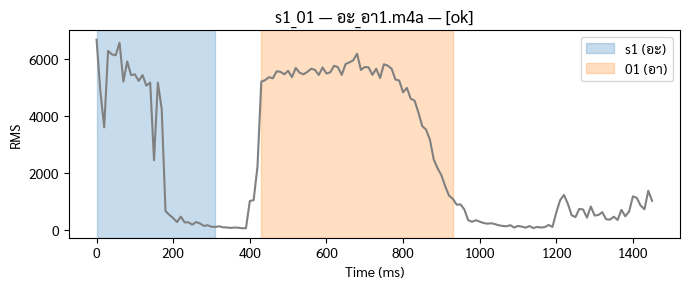

s1_01 | อะ_อา1.m4a | status=ok peaks_ms=[60, 680]



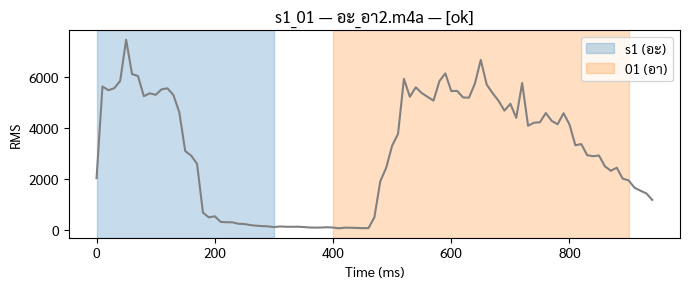

s1_01 | อะ_อา2.m4a | status=ok peaks_ms=[50, 650]



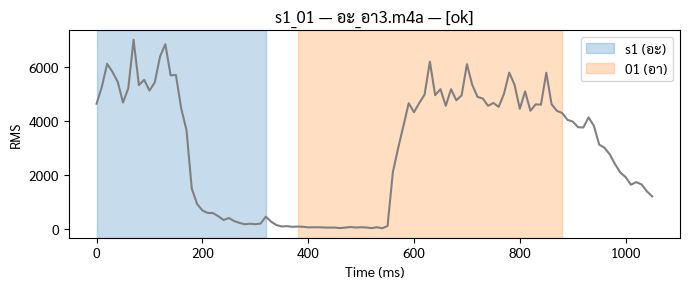

s1_01 | อะ_อา3.m4a | status=ok peaks_ms=[70, 630]



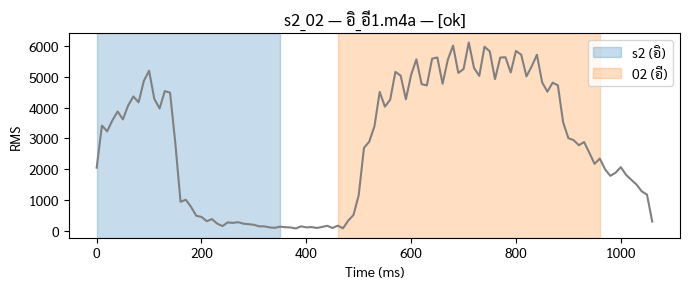

s2_02 | อิ_อี1.m4a | status=ok peaks_ms=[100, 710]



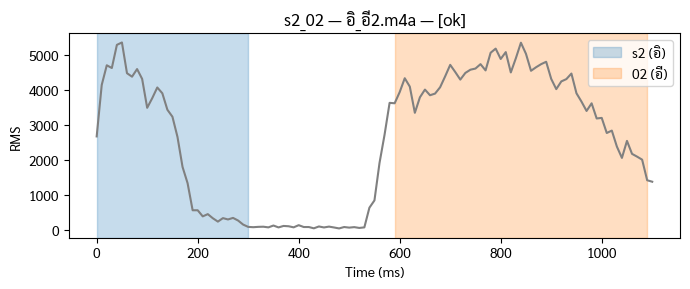

s2_02 | อิ_อี2.m4a | status=ok peaks_ms=[50, 840]



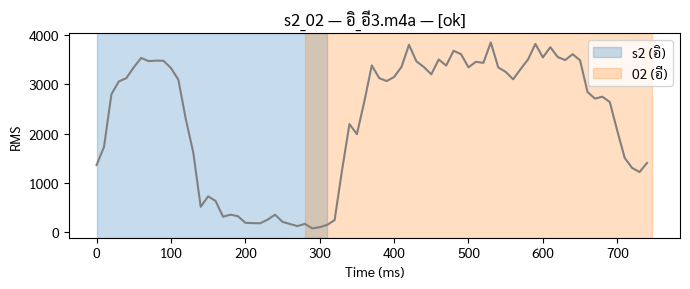

s2_02 | อิ_อี3.m4a | status=ok peaks_ms=[60, 530]



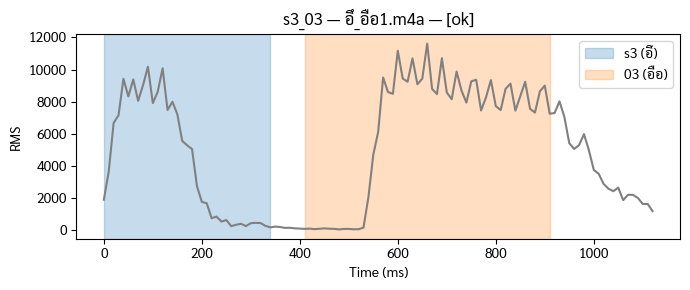

s3_03 | อึ_อือ1.m4a | status=ok peaks_ms=[90, 660]



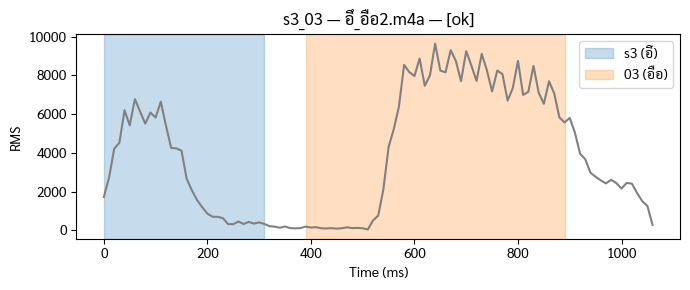

s3_03 | อึ_อือ2.m4a | status=ok peaks_ms=[60, 640]



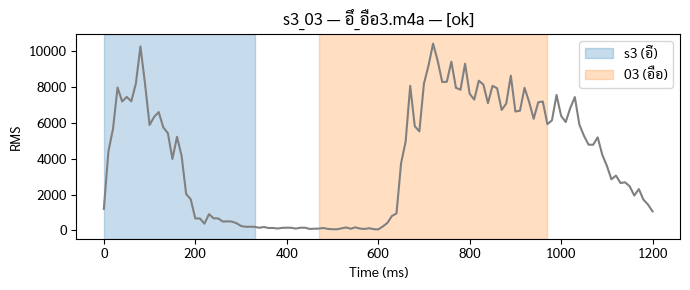

s3_03 | อึ_อือ3.m4a | status=ok peaks_ms=[80, 720]



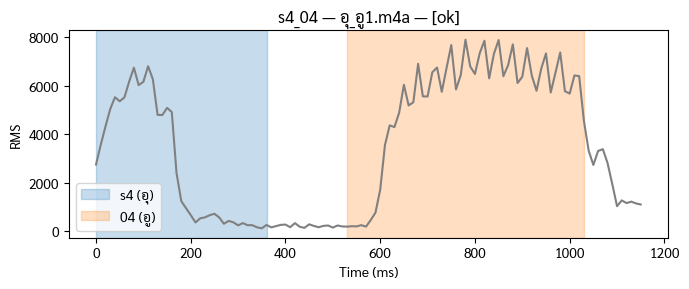

s4_04 | อุ_อู1.m4a | status=ok peaks_ms=[110, 780]



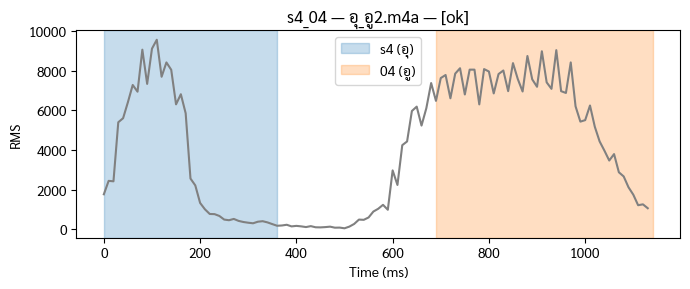

s4_04 | อุ_อู2.m4a | status=ok peaks_ms=[110, 940]



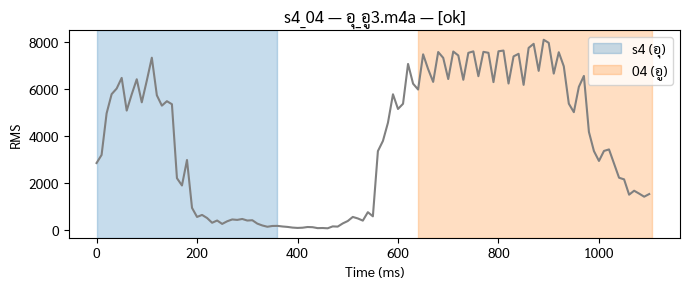

s4_04 | อุ_อู3.m4a | status=ok peaks_ms=[110, 890]



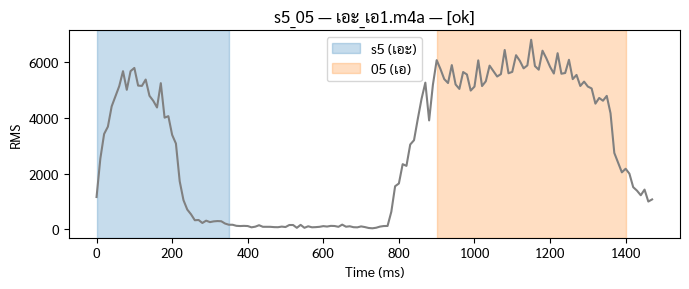

s5_05 | เอะ_เอ1.m4a | status=ok peaks_ms=[100, 1150]



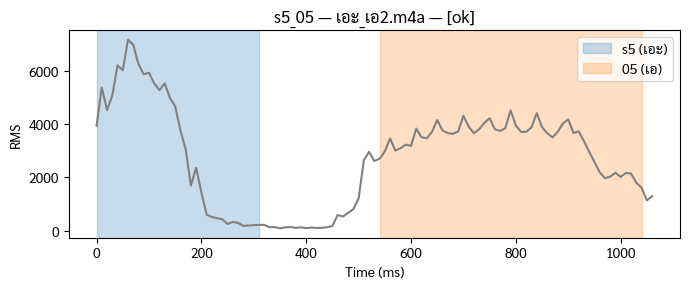

s5_05 | เอะ_เอ2.m4a | status=ok peaks_ms=[60, 790]



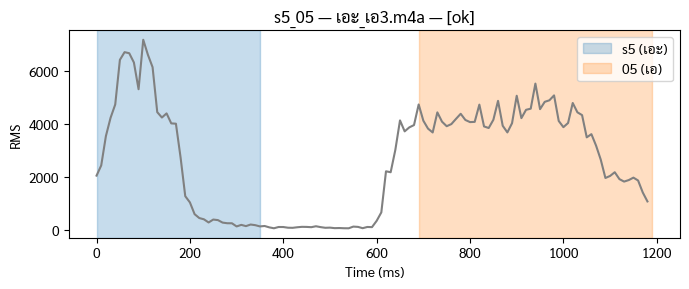

s5_05 | เอะ_เอ3.m4a | status=ok peaks_ms=[100, 940]



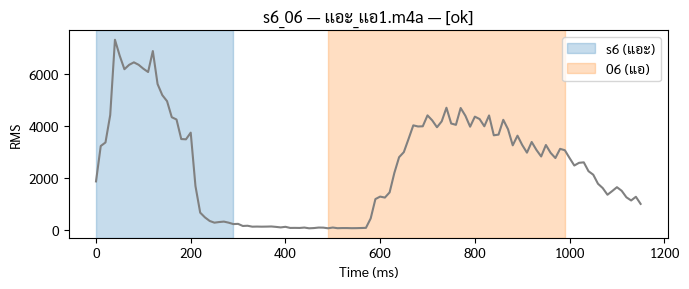

s6_06 | เเอะ_เเอ1.m4a | status=ok peaks_ms=[40, 740]



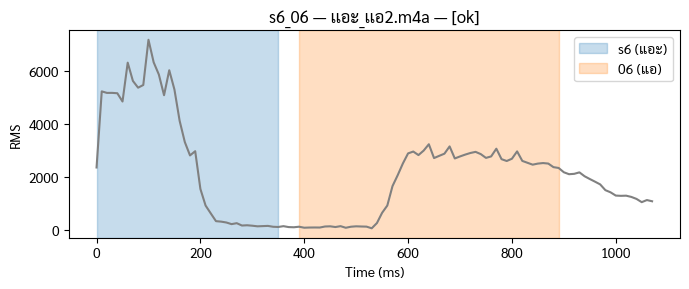

s6_06 | เเอะ_เเอ2.m4a | status=ok peaks_ms=[100, 640]



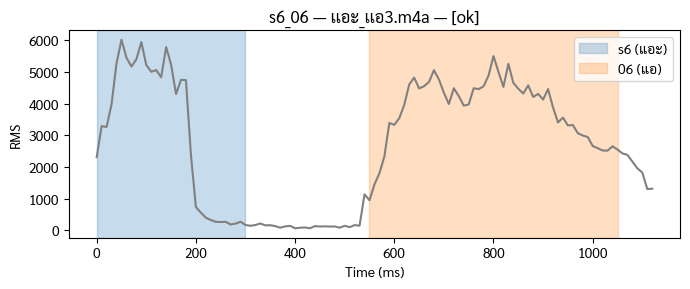

s6_06 | เเอะ_เเอ3.m4a | status=ok peaks_ms=[50, 800]



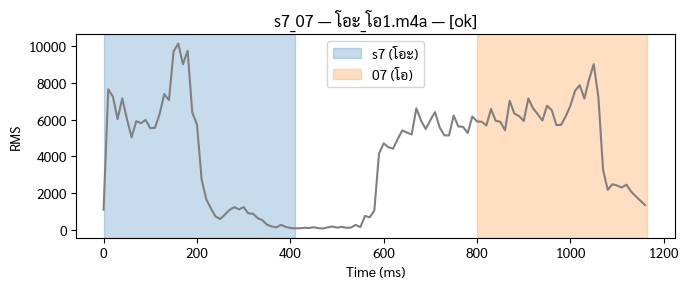

s7_07 | โอะ_โอ1.m4a | status=ok peaks_ms=[160, 1050]



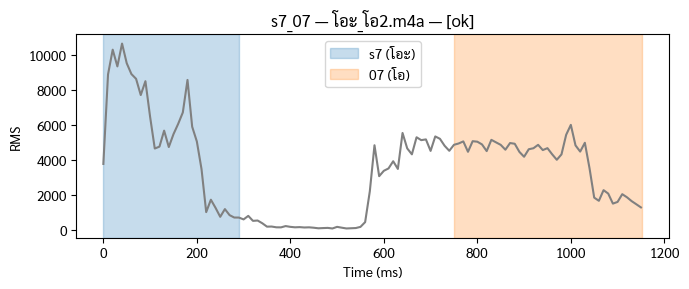

s7_07 | โอะ_โอ2.m4a | status=ok peaks_ms=[40, 1000]



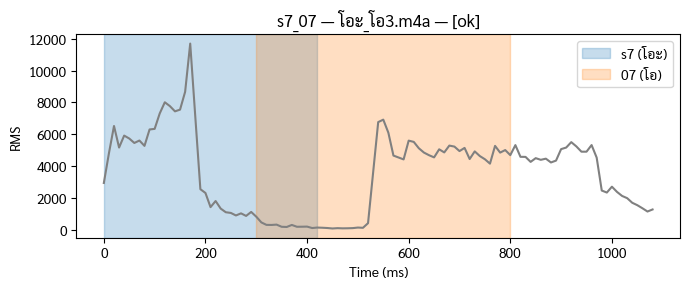

s7_07 | โอะ_โอ3.m4a | status=ok peaks_ms=[170, 550]



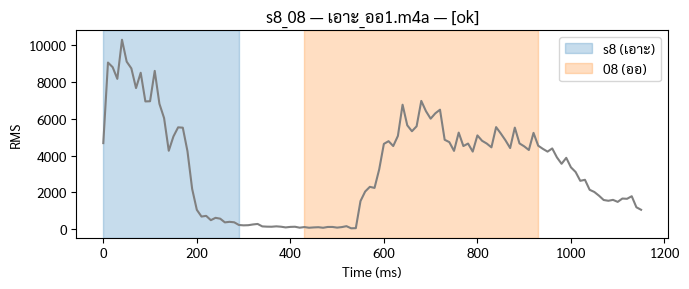

s8_08 | เอาะ_ออ1.m4a | status=ok peaks_ms=[40, 680]



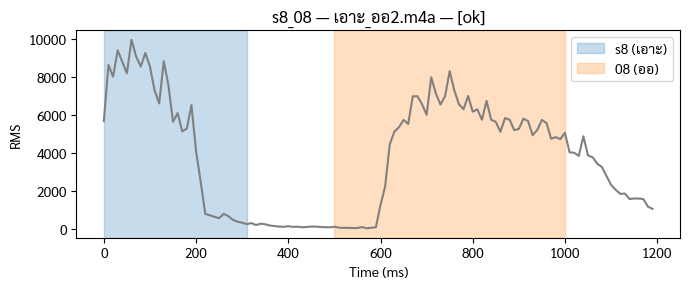

s8_08 | เอาะ_ออ2.m4a | status=ok peaks_ms=[60, 750]



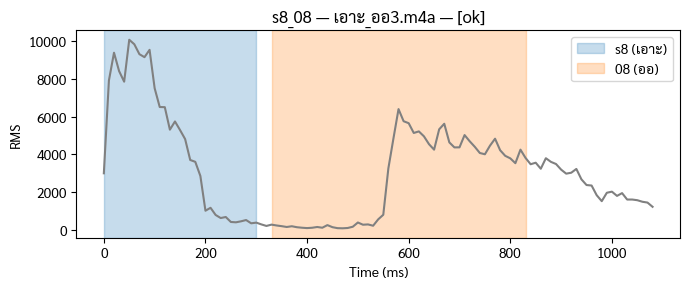

s8_08 | เอาะ_ออ3.m4a | status=ok peaks_ms=[50, 580]



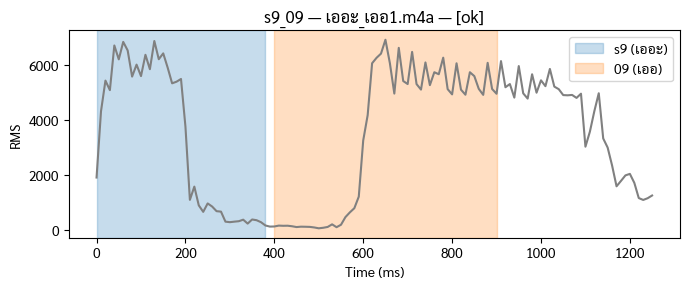

s9_09 | เออะ_เออ1.m4a | status=ok peaks_ms=[130, 650]



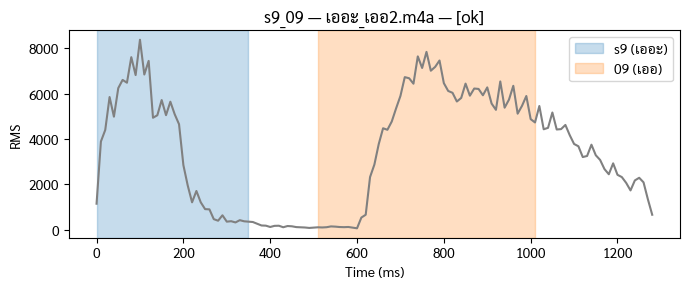

s9_09 | เออะ_เออ2.m4a | status=ok peaks_ms=[100, 760]



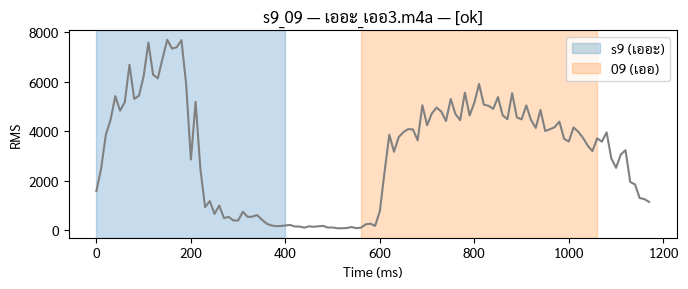

s9_09 | เออะ_เออ3.m4a | status=ok peaks_ms=[150, 810]



In [5]:
def plot_twin_crop(trimmed, energies, result):
    fig, ax = plt.subplots(figsize=(7, 3))
    t_ms = np.arange(len(energies)) * CHUNK_MS
    colors = ['tab:blue', 'tab:orange']

    ax.plot(t_ms, energies, color='gray')
    for seg, color in zip(result['segments'], colors):
        ax.axvspan(seg['crop_start_ms'], seg['crop_end_ms'], alpha=0.25, color=color,
                   label=f"{seg['label']} ({seg['thai']})")
    ax.set_title(f"{result['pair_label']} — {os.path.basename(result['file_path'])} — [{result['status']}]")
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('RMS')
    ax.legend()
    plt.tight_layout()
    plt.show()


all_results = []
for _, row in df_pair.iterrows():
    result, trimmed, energies = crop_twin_segments(row['file_path'], row['pair_label'])
    all_results.append(result)
    plot_twin_crop(trimmed, energies, result)
    print(f"{row['pair_label']} | {os.path.basename(row['file_path'])} "
          f"| status={result['status']} peaks_ms={result['peaks_ms']}\n")


## Section — โหลดโมเดลจริง

ใช้ preprocessing เดียวกับ `m1_realworld.ipynb` (mel spectrogram + CMVN, ไม่ใช่ `wav2mfcc` จาก `vowelserver.py`) เพราะโมเดล `.h5` เทรนมาด้วย mel — ต้องให้ตรงกับตอน train ไม่งั้น predict จะผิดเพี้ยนทันที

In [6]:
import tensorflow as tf
import librosa
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder

SR         = 16000
HOP_LENGTH = 512
N_FFT      = 2048
N_MELS     = 128
MAX_LEN    = 18
MODEL_PATH = 'Models/cnnlstm_mel_model.h5'  



le = LabelEncoder()
le.fit(sorted(FOLDER_TO_THAI.keys()))  
print('Class order:', list(le.classes_))


def extract_mel(file_path, max_len=MAX_LEN):
    """เหมือน m1_realworld.ipynb เป๊ะ — ต้องตรงกับตอน train ทุก step"""
    wave, _ = librosa.load(file_path, mono=True, sr=SR)
    mel    = librosa.feature.melspectrogram(y=wave, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < max_len:
        mel_db = np.pad(mel_db, ((0, 0), (0, max_len - mel_db.shape[1])), mode='constant')
    else:
        mel_db = mel_db[:, :max_len]

    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    alpha  = 0.5
    mean   = mel_db.mean(axis=1, keepdims=True)
    mel_db = mel_db - alpha * mean
    return mel_db


def predict_segment(wav_path):
    feat = extract_mel(wav_path)
    feat = feat[np.newaxis, ..., np.newaxis]
    prob = model.predict(feat, verbose=0)
    class_id   = int(np.argmax(prob))
    confidence = float(np.max(prob))
    pred_label = le.classes_[class_id]
    return pred_label, confidence, prob[0]


2026-08-13 21:32:42.095366: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-13 21:32:42.189150: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-13 21:32:44.135026: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Class order: [np.str_('01'), np.str_('02'), np.str_('03'), np.str_('04'), np.str_('05'), np.str_('06'), np.str_('07'), np.str_('08'), np.str_('09'), np.str_('s1'), np.str_('s2'), np.str_('s3'), np.str_('s4'), np.str_('s5'), np.str_('s6'), np.str_('s7'), np.str_('s8'), np.str_('s9')]


In [7]:
import keras; print(keras.__version__)
import tensorflow as tf; print(tf.__version__)

3.12.1
2.20.0


In [8]:
from tensorflow.keras import layers
@tf.keras.utils.register_keras_serializable()
class BahdanauAttention(layers.Layer):
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units)
        self.V = layers.Dense(1)

    def call(self, lstm_output):
        score   = self.V(tf.nn.tanh(self.W(lstm_output)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * lstm_output, axis=1)
        return context, weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.W.units})
        return config

In [9]:

from keras.src.layers.core.dense import Dense
_original_init = Dense.__init__

def _patched_init(self, *args, **kwargs):
    kwargs.pop('quantization_config', None)
    _original_init(self, *args, **kwargs)

Dense.__init__ = _patched_init


model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={"BahdanauAttention": BahdanauAttention}
)
print(f'Model loaded: {MODEL_PATH}')
print(f'Model input shape: {model.input_shape}')

I0000 00:00:1786631565.652897   23114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model loaded: Models/cnnlstm_mel_model.h5
Model input shape: (None, 128, 18, 1)


## Section — ส่ง segment ที่ตัดได้ (วิธี frontback) เข้าโมเดล predict จริง

In [10]:
predict_rows = []

for result in all_results:  # all_results เก็บผล frontback ไว้จาก section ก่อนหน้า
    if result['status'] != 'ok':
        continue  # segment ไม่ครบ 2 ชิ้น ข้ามไปก่อน ยังพยากรณ์ไม่ได้

    for seg in result['segments']:
        pred_label, confidence, _ = predict_segment(seg['out_path'])
        expected_label = seg['label']
        correct = (pred_label == expected_label)

        predict_rows.append({
            'pair_label'     : result['pair_label'],
            'source_file'    : os.path.basename(result['file_path']),
            'segment_label'  : expected_label,
            'segment_thai'   : seg['thai'],
            'predicted_label': pred_label,
            'predicted_thai' : FOLDER_TO_THAI[pred_label],
            'confidence'     : round(confidence, 4),
            'correct'        : correct,
        })

df_predict = pd.DataFrame(predict_rows)
print(df_predict.to_string(index=False))

if len(df_predict) > 0:
    acc = df_predict['correct'].mean()
    print(f'\nAccuracy on segmented pairs: {acc*100:.1f}% ({len(df_predict)} segments)')

    # แยกดูว่า short vs long ฝั่งไหนแม่นกว่ากัน — ตรงประเด็นวิจัยหลัก
    df_predict['vowel_type'] = df_predict['segment_label'].apply(lambda x: 'short' if x.startswith('s') else 'long')
    print('\nAccuracy by vowel type:')
    print(df_predict.groupby('vowel_type')['correct'].mean())

df_predict.to_csv('twin_peak_predict_results.csv', index=False, encoding='utf-8-sig')


/home/wara/anaconda3/envs/thesis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-08-13 21:32:59.627308: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300


pair_label   source_file segment_label segment_thai predicted_label predicted_thai  confidence  correct
     s1_01    อะ_อา1.m4a            s1           อะ              s1             อะ      0.9209     True
     s1_01    อะ_อา1.m4a            01           อา              01             อา      0.9057     True
     s1_01    อะ_อา2.m4a            s1           อะ              s1             อะ      0.9209     True
     s1_01    อะ_อา2.m4a            01           อา              01             อา      0.9121     True
     s1_01    อะ_อา3.m4a            s1           อะ              s1             อะ      0.9215     True
     s1_01    อะ_อา3.m4a            01           อา              01             อา      0.9182     True
     s2_02    อิ_อี1.m4a            s2           อิ              s2             อิ      0.7062     True
     s2_02    อิ_อี1.m4a            02           อี              02             อี      0.9111     True
     s2_02    อิ_อี2.m4a            s2           อิ             